PROJECT OVERVIEW:
This script automates the retrieval, cleaning, and merging of professional golf 
statistics. It transforms raw, inconsistent CSV files from multiple seasons 
into a standardized, analysis-ready dataset.

CLEANING STEPS:
1. NAME STANDARDIZATION:
   - Converts all names to UPPERCASE for source matching.
   - Strips parenthetical years (e.g., 'AARON BADDELEY (2024)' -> 'AARON BADDELEY').
   
2. NUMERIC EXTRACTION (STRING STRIPPING):
   - Uses RegEx to purge symbols ($, %, ,) and text (T-, Rank).
   - Converts columns to float types for mathematical analysis.

3. SCHEMA COALESCING (COLUMN MERGING):
   - Maps inconsistent headers (e.g., 'Official Money' vs 'MONEY') to Master Columns.
   - Uses backfilling to collapse data into a single reliable metric.

4. STRICT QUALITY FILTERING:
   - Removes rows missing a 'Year'.
   - PURGE LOGIC: Discards rows that ONLY contain Name/Year/Wins/Money.
   - Requirement: A row MUST contain at least one core performance metric 
     (Rounds, Distance, GIR, SG Total, or Scoring Average) to be kept.
"""

In [5]:

import pandas as pd
import re
import numpy as np

# --- 1. DEFINE YOUR SOURCE URLS ---
raw_perf_url = "https://raw.githubusercontent.com/jachengl-alt/pgatour-performance-data/refs/heads/main/pga_raw_combined_master.csv"
winners_url = "https://raw.githubusercontent.com/jachengl-alt/pgatour-performance-data/refs/heads/main/data%20used%20for%20pga%20raw%20combined%20csv/pga_full_history_2000_2026%20copy.csv"
OUTPUT_FILE = "PGA_Data_Master_Cleaned.csv"

def clean_name(name):
    """Standardizes names and removes year parentheticals."""
    if pd.isna(name): return name
    name = re.sub(r'\s*\(\d+\)', '', str(name))
    return name.strip().upper()

def clean_numeric(x):
    """Strips all non-numeric characters (strings, %, $) and converts to float."""
    if pd.isna(x) or str(x).strip() == "": 
        return np.nan
    clean_str = re.sub(r'[^\d.-]', '', str(x))
    try:
        return float(clean_str)
    except ValueError:
        return np.nan

def combine_cols(df, col_list):
    """Coalesces multiple column variations into one."""
    existing = [c for c in col_list if c in df.columns]
    if not existing:
        return pd.Series([np.nan] * len(df))
    return df[existing].bfill(axis=1).iloc[:, 0]

# --- Step 1: Loading Data ---
print("Step 1: Downloading data from GitHub...")
try:
    df = pd.read_csv(raw_perf_url, encoding='latin1', low_memory=False)
    df_hist = pd.read_csv(winners_url, encoding='latin1')
except Exception as e:
    print(f"Connection Error: {e}")
    exit()

# --- Step 2: Processing Performance Stats ---
print("Step 2: Merging and cleaning columns...")
df['PLAYER NAME'] = df['PLAYER NAME'].apply(clean_name)

column_map = {
    'Master_Money': ['MONEY', 'Official Money', 'Money', 'FINISHES_OFFICIAL_MONEY'],
    'Master_Dist': ['DRIVE_DISTANCE', 'Avg Distance', 'TEE_AVG_DRIVING_DISTANCE', 'Driving Distance'],
    'Master_GIR': ['GIR_%', 'gir', 'GIR_PCT_OVERALL'],
    'Master_Score': ['SCORING', 'Average Score', 'SCORING_AVG_OVERALL'],
    'Master_SGT': ['SG_T', 'Average SG Total', 'SG: Total'],
    'Master_Rounds': ['ROUNDS', 'Rounds']
}

for master, variants in column_map.items():
    df[master] = combine_cols(df, variants)

clean_df = pd.DataFrame({
    'Player': df['PLAYER NAME'],
    'Year': pd.to_numeric(df['Year'], errors='coerce'),
    'Rounds': df['Master_Rounds'].apply(clean_numeric),
    'Avg_Drive_Distance': df['Master_Dist'].apply(clean_numeric),
    'GIR_Percentage': df['Master_GIR'].apply(clean_numeric),
    'SG_Total': df['Master_SGT'].apply(clean_numeric),
    'Scoring_Avg': df['Master_Score'].apply(clean_numeric),
    'Money': df['Master_Money'].apply(clean_numeric)
})

# --- Step 3: Merging Win History ---
print("Step 3: Merging win history...")
df_hist['Winner'] = df_hist['Winner'].apply(clean_name)
year_col = 'Season' if 'Season' in df_hist.columns else 'Year'

wins_agg = df_hist.groupby(['Winner', year_col]).agg(
    Wins=('Tournament', 'count'),
    Tournaments_Won=('Tournament', lambda x: ', '.join(x.astype(str)))
).reset_index()

final_df = pd.merge(clean_df, wins_agg, left_on=['Player', 'Year'], right_on=['Winner', year_col], how='left')
final_df['Wins'] = final_df['Wins'].fillna(0).astype(int)
final_df['Tournaments_Won'] = final_df['Tournaments_Won'].fillna("")
final_df.drop(columns=['Winner', year_col], inplace=True, errors='ignore')

# --- Step 4: Strict Performance Filtering ---
print("Step 4: Removing rows that ONLY have Money/Wins...")

# We define "Essential Stats" here. 
# We EXCLUDE Money and Wins. 
# A row MUST have at least one of these to stay in the file.
performance_metrics = ['Rounds', 'Avg_Drive_Distance', 'GIR_Percentage', 'SG_Total', 'Scoring_Avg']

# 1. Remove rows without a year
final_df = final_df.dropna(subset=['Year'])

# 2. Remove rows where all 'performance_metrics' are NaN.
# This deletes rows that only have Player/Year/Money/Wins.
final_df = final_df.dropna(subset=performance_metrics, how='all')

# Final sorting and deduplication
final_df.sort_values(by=['Year', 'Player'], inplace=True)
final_df.drop_duplicates(subset=['Player', 'Year'], inplace=True)

# Export
final_df.to_csv(OUTPUT_FILE, index=False)

print("\n--- PROCESS COMPLETE ---")
print(f"Final dataset has {len(final_df)} high-quality rows.")
print(f"Saved to: {OUTPUT_FILE}")

Step 1: Downloading data from GitHub...
Step 2: Merging and cleaning columns...
Step 3: Merging win history...
Step 4: Removing rows that ONLY have Money/Wins...

--- PROCESS COMPLETE ---
Final dataset has 2449 high-quality rows.
Saved to: PGA_Data_Master_Cleaned.csv



## This heatmap calculates the Pearson Correlation Coefficient between different performance metrics. It allows us to see which variables move together. For instance, a strong negative correlation between SG_Total (Strokes Gained Total) and Scoring_Avg indicates that as a player's strokes gained increase, their score decreases. This visualization is essential for Feature Selection, helping me decide which variables are the most powerful predictors to include in the Machine Learning model.

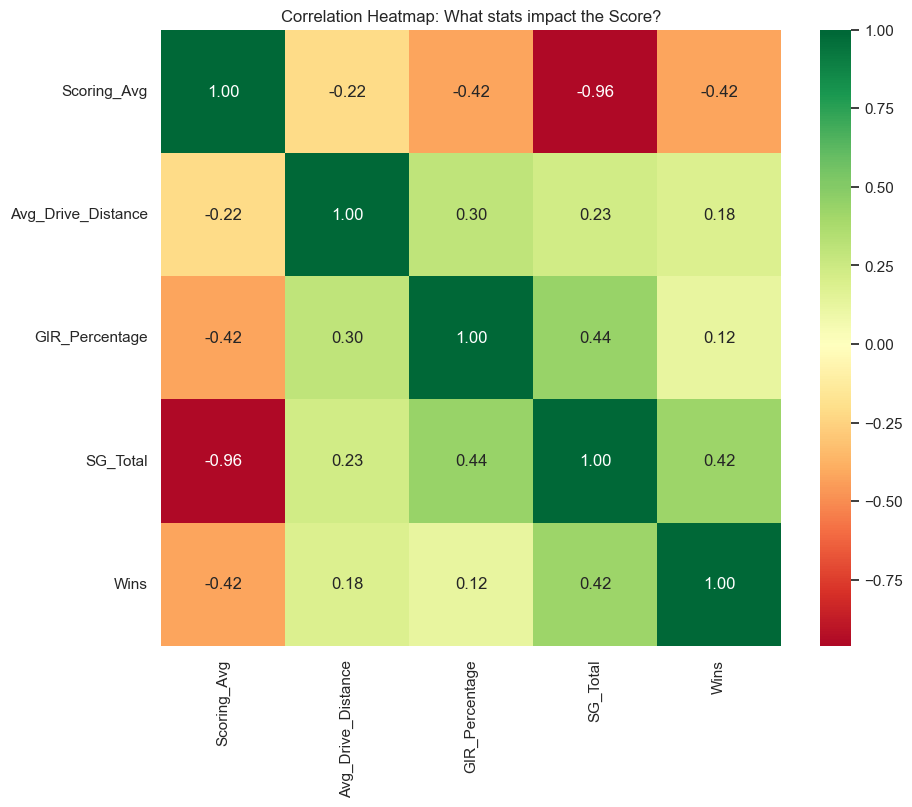

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the visual style is clean
sns.set_theme(style="white")

# Select the columns we want to compare
# These must match your 'final_df' column names exactly
cols = ['Scoring_Avg', 'Avg_Drive_Distance', 'GIR_Percentage', 'SG_Total', 'Wins']

plt.figure(figsize=(10, 8))
corr = final_df[cols].corr()

# Create the heatmap
sns.heatmap(corr, annot=True, cmap='RdYlGn', fmt=".2f", center=0)
plt.title('Correlation Heatmap: What stats impact the Score?')

# Save to your output folder
plt.savefig('../output/figures/correlation_heatmap.png')
plt.show()

## This histogram displays the frequency of player scoring averages across the dataset. By applying a Kernel Density Estimate (KDE) line, we can confirm that the data follows a Normal Distribution (a "Bell Curve"). Understanding this distribution is a critical pre-processing step for linear regression, as it ensures there is enough variance in our target variable (Scoring_Avg) and identifies any extreme outliers that might skew our results.

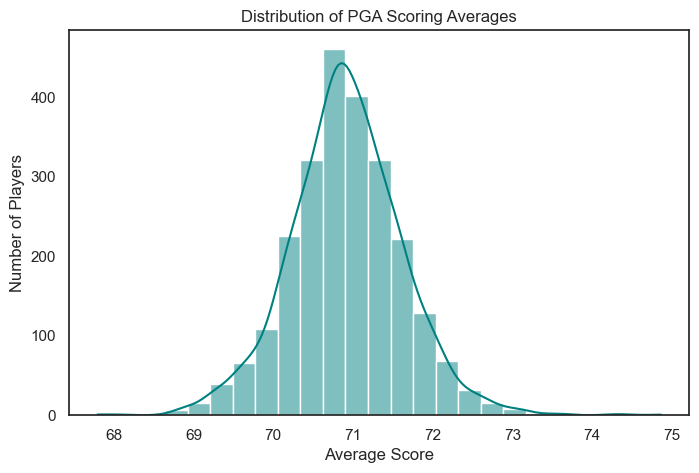

In [7]:
# --- 2. Distribution of Scoring Average ---
plt.figure(figsize=(8, 5))

# Using final_df which we loaded in the previous step
sns.histplot(final_df['Scoring_Avg'], bins=25, kde=True, color='teal')

plt.title('Distribution of PGA Scoring Averages')
plt.xlabel('Average Score')
plt.ylabel('Number of Players')

# Save to your organized folder
plt.savefig('../output/figures/scoring_distribution.png')
plt.show()

## This scatter plot explores the bivariate relationship between GIR Percentage (Greens in Regulation) and the Scoring Average. By adding a Regression Line (the red line), we can visually confirm a clear downward trend: players who hit a higher percentage of greens consistently card lower scores. This plot provides "proof of concept" that the physical stats we scraped are logically linked to a player's final output.

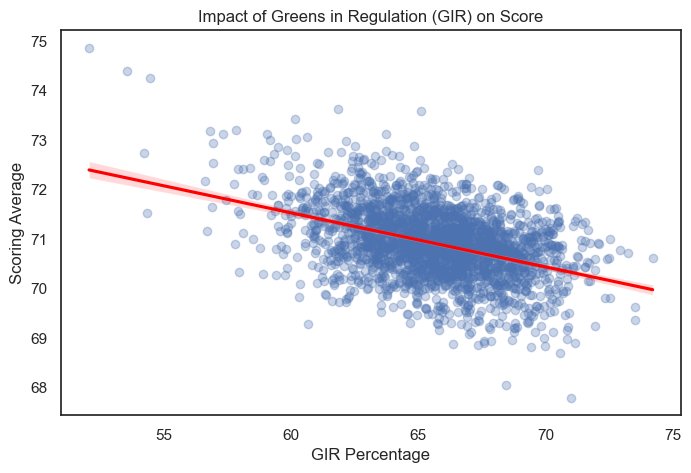

In [8]:
# --- 3. Relationship: GIR vs Scoring Average ---
plt.figure(figsize=(8, 5))

# regplot adds a "trend line" which looks very professional for a project
sns.regplot(data=final_df, x='GIR_Percentage', y='Scoring_Avg', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

plt.title('Impact of Greens in Regulation (GIR) on Score')
plt.xlabel('GIR Percentage')
plt.ylabel('Scoring Average')

# Save to your organized folder
plt.savefig('../output/figures/gir_vs_score_scatter.png')
plt.show()